# 03 · Entrenamiento y Evaluación

Entrena un clasificador de señas WH sobre los landmarks augmentados.
El código detecta automáticamente las clases disponibles — agregar una seña nueva
es tan simple como poner sus clips en `data/clips/` y reejecutar los notebooks anteriores.

**Flujo:**
1. Cargar y preparar dataset
2. Baseline SVM
3. LSTM (opcional, para cuando haya más datos)
4. Evaluación y matriz de confusión
5. Guardar modelo

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

AUG_DIR   = Path('./data/landmarks_aug')
MODELS_DIR = Path('./models')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Largo fijo al que se normalizan todos los clips (frames)
N_FRAMES_FIJO = 60

# Clases detectadas automáticamente — orden alfabético = orden de etiquetas
CLASES = sorted([c.name for c in AUG_DIR.iterdir() if c.is_dir()])

print(f'Clases detectadas ({len(CLASES)}): {CLASES}')
print(f'Frames fijos por clip: {N_FRAMES_FIJO}')
print(f'Modelos se guardan en: {MODELS_DIR.resolve()}')

Clases detectadas (5): ['DONDE', 'NADA', 'POR_QUE', 'QUE1', 'QUIEN1']
Frames fijos por clip: 60
Modelos se guardan en: /home/pierov/piero/projects/whqlsp-detector/notebooks/models


## Sección 1 — Cargar y preparar el dataset

In [2]:
def normalizar_longitud(landmarks: np.ndarray, n_frames: int) -> np.ndarray:
    """
    Interpola la secuencia de landmarks a exactamente n_frames.
    Necesario porque los clips tienen distinta cantidad de frames.
    Input:  (T, 2, 21, 3)
    Output: (n_frames, 2, 21, 3)
    """
    T = landmarks.shape[0]
    if T == n_frames:
        return landmarks
    indices = np.linspace(0, T - 1, n_frames)
    resultado = np.zeros((n_frames, *landmarks.shape[1:]), dtype=np.float32)
    for i, idx in enumerate(indices):
        i0 = int(idx)
        i1 = min(i0 + 1, T - 1)
        alpha = idx - i0
        resultado[i] = landmarks[i0] * (1 - alpha) + landmarks[i1] * alpha
    return resultado


def cargar_dataset(aug_dir: Path, clases: list, n_frames: int):
    """
    Carga todos los .npy, normaliza a n_frames y genera X e y.
    
    X shape: (n_clips, n_frames * 2 * 21 * 3) = (n_clips, n_frames * 126)
    y shape: (n_clips,) — etiquetas de texto
    """
    X, y, nombres = [], [], []

    for clase in clases:
        npy_files = sorted((aug_dir / clase).glob('*.npy'))
        print(f'  {clase:<15} {len(npy_files)} clips')

        for npy_path in npy_files:
            landmarks = np.load(npy_path)          # (T, 2, 21, 3)
            landmarks = normalizar_longitud(landmarks, n_frames)  # (n_frames, 2, 21, 3)
            vector = landmarks.flatten()            # (n_frames * 126,)
            X.append(vector)
            y.append(clase)
            nombres.append(npy_path.stem)

    X = np.array(X, dtype=np.float32)
    y = np.array(y)
    return X, y, nombres

In [3]:
print('Cargando dataset...\n')
X, y, nombres = cargar_dataset(AUG_DIR, CLASES, N_FRAMES_FIJO)

print(f'\nDataset cargado:')
print(f'  X shape: {X.shape}  ({X.shape[0]} clips × {X.shape[1]} features)')
print(f'  Clases:  {dict(zip(*np.unique(y, return_counts=True)))}')

Cargando dataset...

  DONDE           66 clips
  NADA            288 clips
  POR_QUE         72 clips
  QUE1            36 clips
  QUIEN1          42 clips

Dataset cargado:
  X shape: (504, 7560)  (504 clips × 7560 features)
  Clases:  {np.str_('DONDE'): np.int64(66), np.str_('NADA'): np.int64(288), np.str_('POR_QUE'): np.int64(72), np.str_('QUE1'): np.int64(36), np.str_('QUIEN1'): np.int64(42)}


In [4]:
# Encode etiquetas a números
le = LabelEncoder()
y_enc = le.fit_transform(y)

print('Encoding de etiquetas:')
for i, clase in enumerate(le.classes_):
    print(f'  {i} → {clase}')

Encoding de etiquetas:
  0 → DONDE
  1 → NADA
  2 → POR_QUE
  3 → QUE1
  4 → QUIEN1


## Sección 2 — Baseline SVM

SVM con kernel RBF. Rápido de entrenar, funciona bien con pocos datos y features de alta dimensión.
Usamos cross-validation estratificada para evaluar de forma robusta con el dataset pequeño.

In [5]:
# Pipeline: normalización + SVM
# StandardScaler es importante — los landmarks tienen escalas distintas en x, y, z
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC(kernel='rbf', C=10, gamma='scale',
                   probability=True, random_state=42))
])

# Cross-validation estratificada (mantiene proporción de clases en cada fold)
# Con pocos datos usamos 5 folds
n_folds = min(5, min(np.bincount(y_enc)))  # no más folds que ejemplos por clase
cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

print(f'Cross-validation con {n_folds} folds...')
scores = cross_val_score(svm_pipeline, X, y_enc, cv=cv, scoring='accuracy')

print(f'\nResultados SVM:')
print(f'  Accuracy por fold: {[f"{s:.3f}" for s in scores]}')
print(f'  Media:             {scores.mean():.3f}')
print(f'  Desv. estándar:    {scores.std():.3f}')

if scores.mean() > 0.85:
    print('\n✓ Buen resultado — el modelo distingue bien las señas')
elif scores.mean() > 0.70:
    print('\n~ Resultado aceptable — más datos mejorarían el modelo')
else:
    print('\n⚠ Resultado bajo — revisar calidad de landmarks o agregar más datos')

Cross-validation con 5 folds...


/home/pierov/piero/projects/whqlsp-detector/.venv/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/pierov/piero/projects/whqlsp-detector/.venv/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/pierov/piero/projects/whqlsp-detector/.venv/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/pierov/piero/projects/whqlsp-detector/.venv/lib/python3.11/si


Resultados SVM:
  Accuracy por fold: ['0.941', '0.871', '0.941', '0.921', '0.930']
  Media:             0.921
  Desv. estándar:    0.026

✓ Buen resultado — el modelo distingue bien las señas


In [6]:
# Entrenar el modelo final sobre todo el dataset
svm_pipeline.fit(X, y_enc)
print('Modelo SVM entrenado sobre el dataset completo')

/home/pierov/piero/projects/whqlsp-detector/.venv/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Modelo SVM entrenado sobre el dataset completo


## Sección 3 — LSTM (para cuando haya más datos)

El LSTM captura información temporal que el SVM pierde al aplanar la secuencia.
Recomendado cuando tengas ≥20 clips reales por clase.

Descomenta y ejecuta cuando estés listo.

In [ ]:
# ─── DESCOMENTA CUANDO TENGAS MÁS DATOS ───────────────────────────────────────
# 
# import torch
# import torch.nn as nn
# from torch.utils.data import DataLoader, TensorDataset
# from sklearn.model_selection import train_test_split
# 
# def cargar_dataset_secuencial(aug_dir, clases, n_frames):
#     """Igual que cargar_dataset pero SIN aplanar — mantiene (n_frames, 126)."""
#     X, y = [], []
#     for clase in clases:
#         for npy_path in sorted((aug_dir / clase).glob('*.npy')):
#             lm = np.load(npy_path)
#             lm = normalizar_longitud(lm, n_frames)  # (n_frames, 2, 21, 3)
#             lm = lm.reshape(n_frames, -1)           # (n_frames, 126)
#             X.append(lm)
#             y.append(clases.index(clase))
#     return np.array(X, dtype=np.float32), np.array(y)
# 
# 
# class LSP_LSTM(nn.Module):
#     def __init__(self, input_size=126, hidden_size=128, n_layers=2, n_clases=len(CLASES)):
#         super().__init__()
#         self.lstm = nn.LSTM(input_size, hidden_size, n_layers,
#                             batch_first=True, dropout=0.3)
#         self.fc = nn.Sequential(
#             nn.Linear(hidden_size, 64),
#             nn.ReLU(),
#             nn.Dropout(0.3),
#             nn.Linear(64, n_clases)
#         )
# 
#     def forward(self, x):
#         out, _ = self.lstm(x)   # (batch, n_frames, hidden)
#         out = out[:, -1, :]     # último frame
#         return self.fc(out)
# 
# 
# X_seq, y_seq = cargar_dataset_secuencial(AUG_DIR, CLASES, N_FRAMES_FIJO)
# X_tr, X_val, y_tr, y_val = train_test_split(
#     X_seq, y_seq, test_size=0.2, stratify=y_seq, random_state=42
# )
# 
# train_ds = TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr))
# val_ds   = TensorDataset(torch.tensor(X_val), torch.tensor(y_val))
# train_dl = DataLoader(train_ds, batch_size=16, shuffle=True)
# val_dl   = DataLoader(val_ds,   batch_size=16)
# 
# modelo_lstm = LSP_LSTM(n_clases=len(CLASES))
# optimizer   = torch.optim.Adam(modelo_lstm.parameters(), lr=1e-3)
# criterio    = nn.CrossEntropyLoss()
# 
# N_EPOCHS = 50
# for epoch in range(N_EPOCHS):
#     modelo_lstm.train()
#     for xb, yb in train_dl:
#         pred = modelo_lstm(xb)
#         loss = criterio(pred, yb)
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
# 
#     if (epoch + 1) % 10 == 0:
#         modelo_lstm.eval()
#         with torch.no_grad():
#             correcto = sum(
#                 (modelo_lstm(xb).argmax(1) == yb).sum().item()
#                 for xb, yb in val_dl
#             )
#         acc = correcto / len(val_ds)
#         print(f'Epoch {epoch+1:3d}/{N_EPOCHS} — val accuracy: {acc:.3f}')
# 
# torch.save(modelo_lstm.state_dict(), MODELS_DIR / 'lstm_lsp.pt')
# print('Modelo LSTM guardado en models/lstm_lsp.pt')
# ──────────────────────────────────────────────────────────────────────────────

print('LSTM comentado — descomenta cuando tengas ≥20 clips reales por clase')

## Sección 4 — Evaluación y matriz de confusión

In [7]:
# Predicciones sobre el dataset completo (para ver qué confunde el modelo)
# Nota: esto es optimista porque entrenó sobre los mismos datos.
# El número real de generalización es el cross-val de arriba.
y_pred = svm_pipeline.predict(X)
y_pred_labels = le.inverse_transform(y_pred)

print('Reporte de clasificación:')
print(classification_report(y, y_pred_labels, target_names=le.classes_))

Reporte de clasificación:
              precision    recall  f1-score   support

       DONDE       1.00      1.00      1.00        66
        NADA       1.00      1.00      1.00       288
     POR_QUE       1.00      1.00      1.00        72
        QUE1       1.00      1.00      1.00        36
      QUIEN1       1.00      1.00      1.00        42

    accuracy                           1.00       504
   macro avg       1.00      1.00      1.00       504
weighted avg       1.00      1.00      1.00       504



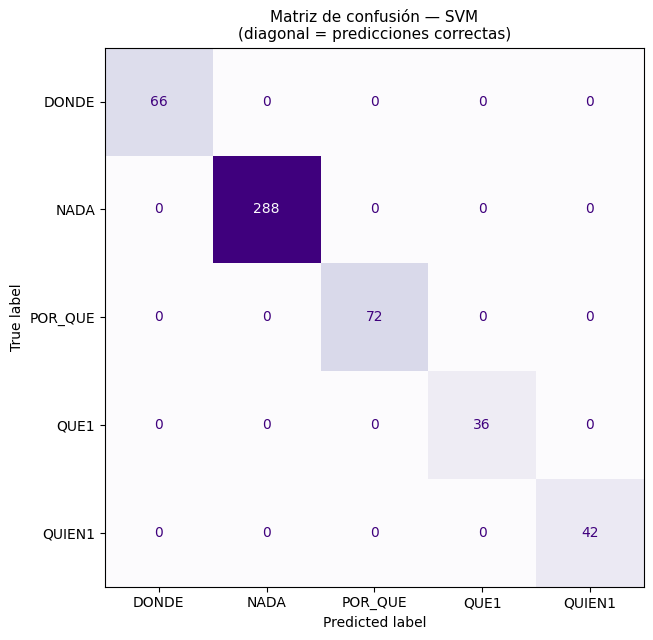

Imagen guardada en data/matriz_confusion.png


In [8]:
# Matriz de confusión
cm = confusion_matrix(y, y_pred_labels, labels=le.classes_)

fig, ax = plt.subplots(figsize=(max(5, len(CLASES) * 1.5),
                                 max(4, len(CLASES) * 1.3)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False, cmap='Purples')
ax.set_title('Matriz de confusión — SVM\n(diagonal = predicciones correctas)',
             fontsize=11)
plt.tight_layout()
plt.savefig('./data/matriz_confusion.png', dpi=120, bbox_inches='tight')
plt.show()
print('Imagen guardada en data/matriz_confusion.png')

In [9]:
# Ver probabilidades de predicción para cada clip
# Útil para detectar clips donde el modelo duda
probs = svm_pipeline.predict_proba(X)

print('Clips con baja confianza (< 0.70):\n')
hay_dudas = False
for i, (nombre, clase_real, prob) in enumerate(zip(nombres, y, probs)):
    confianza = prob.max()
    clase_pred = le.classes_[prob.argmax()]
    if confianza < 0.70:
        hay_dudas = True
        estado = '✓' if clase_pred == clase_real else '✗'
        print(f'  {estado} {nombre:<30} real={clase_real:<12} '
              f'pred={clase_pred:<12} conf={confianza:.2f}')

if not hay_dudas:
    print('  Ninguno — el modelo predice con alta confianza en todos los clips')

Clips con baja confianza (< 0.70):

  Ninguno — el modelo predice con alta confianza en todos los clips


## Sección 5 — Guardar el modelo

In [10]:
# Guardar todo lo necesario para inferencia en un solo archivo
modelo_bundle = {
    'pipeline':     svm_pipeline,   # scaler + SVM entrenados
    'label_encoder': le,            # para convertir número → nombre de seña
    'clases':       CLASES,         # lista de clases en orden
    'n_frames':     N_FRAMES_FIJO,  # parámetro necesario para inferencia
    'cv_accuracy':  scores.mean(),  # métrica de referencia
    'tipo':         'svm',
}

model_path = MODELS_DIR / 'svm_lsp.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(modelo_bundle, f)

print(f'Modelo guardado en: {model_path}')
print(f'  Clases:      {CLASES}')
print(f'  CV accuracy: {scores.mean():.3f}')
print(f'  N frames:    {N_FRAMES_FIJO}')

Modelo guardado en: models/svm_lsp.pkl
  Clases:      ['DONDE', 'NADA', 'POR_QUE', 'QUE1', 'QUIEN1']
  CV accuracy: 0.921
  N frames:    60


In [11]:
# Verificar que el modelo guardado carga y predice correctamente
with open(model_path, 'rb') as f:
    bundle_cargado = pickle.load(f)

pred_test = bundle_cargado['pipeline'].predict(X[:3])
etiquetas_test = bundle_cargado['label_encoder'].inverse_transform(pred_test)

print('Verificación del modelo guardado:')
for i, (real, pred) in enumerate(zip(y[:3], etiquetas_test)):
    estado = '✓' if real == pred else '✗'
    print(f'  {estado} clip {i+1}: real={real} pred={pred}')

print('\nModelo listo para integrar en FastAPI (endpoint /analyze)')

Verificación del modelo guardado:
  ✓ clip 1: real=DONDE pred=DONDE
  ✓ clip 2: real=DONDE pred=DONDE
  ✓ clip 3: real=DONDE pred=DONDE

Modelo listo para integrar en FastAPI (endpoint /analyze)


---
## ¿Qué sigue?

El modelo está en `models/svm_lsp.pkl`.

El siguiente paso es reemplazar el mock en `main.py` (endpoint `POST /analyze/{video_id}`) con inferencia real:
1. Cargar el bundle al arrancar FastAPI
2. Recibir el video, extraer landmarks con MediaPipe
3. Normalizar a `N_FRAMES_FIJO` frames
4. Predecir con `pipeline.predict_proba()`
5. Devolver timestamps + etiqueta + confianza

**Cuando agregues más señas:** agrega los clips, reejecutar notebooks `01 → 02 → 03`, el modelo se reentrenará con las clases nuevas automáticamente.